# Drowsy VS Non Drowsy [CNN]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Menginstal library kaggle di Google Colab
!pip install kaggle

# Data Exploration
import os
import matplotlib.pyplot as plt

# Split Dataset
import pandas as pd
from sklearn.model_selection import train_test_split

# ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Modelling
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evaluasi dan Visualisasi
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Data Preparation

### Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Setup Kaggle API key
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [3]:
# Mengunduh dataset dari Kaggle
!kaggle datasets download -d atharvbheda/employee-drowsiness-detection

Dataset URL: https://www.kaggle.com/datasets/atharvbheda/employee-drowsiness-detection
License(s): unknown
100% 2.38G/2.38G [02:05<00:00, 20.3MB/s]



In [4]:
# Mengekstrak file dataset yang telah diunduh
!unzip -q employee-drowsiness-detection.zip

In [5]:
# Upload dan ekstrak dataset primer
!cp -r "/content/drive/MyDrive/dataset_primer" /content/dataset_primer

### Data Exploration

In [6]:
# Menampilkan daftar nama kelas dan jumlahnya dari folder dataset
image_dataset_sekunder = 'dataset'
image_dataset_primer = 'dataset_primer'

classes = os.listdir(image_dataset_sekunder)
classes_primer = os.listdir(image_dataset_primer)

print("Kelas (sekunder):", classes)
print("Kelas (primer):", classes_primer)
print("Jumlah kelas:", len(classes))

Kelas (sekunder): ['nondrowsy', 'drowsy']
Kelas (primer): ['nondrowsy', 'drowsy']
Jumlah kelas: 2


In [7]:
# Jumlah gambar per kelas
count_sekunder = {cls: len(os.listdir(os.path.join(image_dataset_sekunder, cls))) for cls in classes}
count_primer = {cls: len(os.listdir(os.path.join(image_dataset_primer, cls))) for cls in classes}

for cls in classes:
    total_cls = count_sekunder[cls] + count_primer[cls]
    print(f"{cls}: {total_cls} gambar (sekunder: {count_sekunder[cls]}, primer: {count_primer[cls]})")

total_images = sum(count_sekunder.values()) + sum(count_primer.values())
print("\nTotal semua gambar:", total_images)

nondrowsy: 6270 gambar (sekunder: 6051, primer: 219)
drowsy: 6230 gambar (sekunder: 6019, primer: 211)

Total semua gambar: 12500


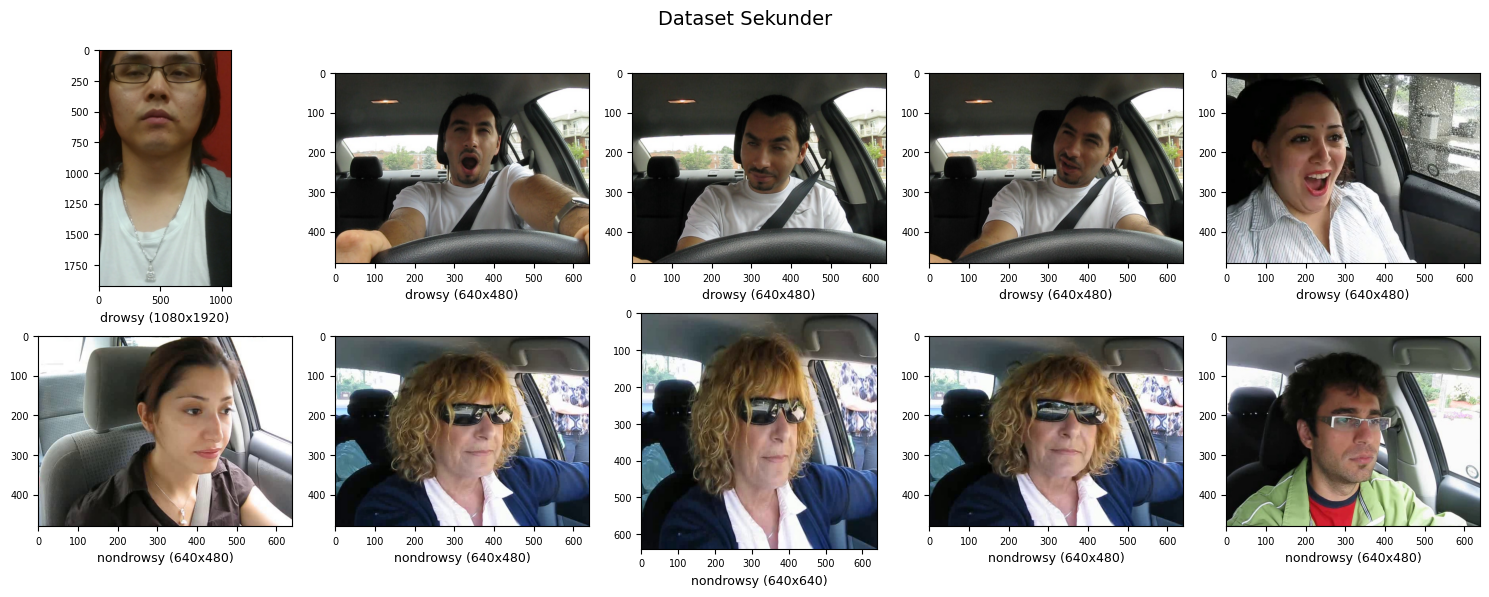

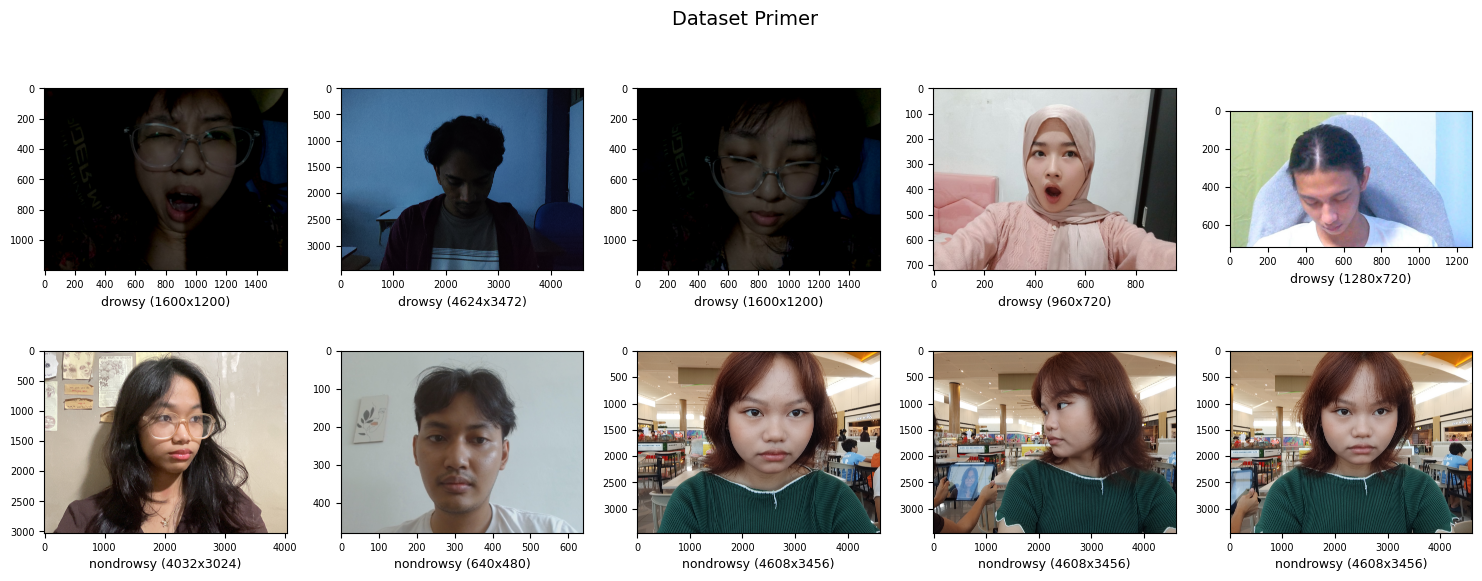

In [8]:
def display_images(image_dataset, classes, source_label, num_images=5):
    sorted_classes = sorted(classes)

    fig, axes = plt.subplots(len(sorted_classes), num_images, figsize=(15, 3 * len(sorted_classes)))
    fig.suptitle(source_label, fontsize=14)

    for row, cls in enumerate(sorted_classes):
        class_path = os.path.join(image_dataset, cls)
        all_images = sorted(os.listdir(class_path))
        images = all_images[:num_images]

        for col, img_file in enumerate(images):
            img_path = os.path.join(class_path, img_file)
            img = plt.imread(img_path)
            h, w = img.shape[0], img.shape[1]

            axes[row, col].imshow(img)
            axes[row, col].set_xlabel(f'{cls} ({w}x{h})', fontsize=9)
            axes[row, col].tick_params(axis='both', labelsize=7)

    plt.tight_layout()
    plt.show()

display_images(image_dataset_sekunder, classes, "Dataset Sekunder", num_images=5)
display_images(image_dataset_primer, classes, "Dataset Primer", num_images=5)

### Data Preprocessing

#### Split Dataset

In [9]:
data = []
for cls in classes:
    class_path = os.path.join(image_dataset_sekunder, cls)
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            data.append({'filepath': os.path.join(class_path, fname), 'label': cls, 'source': 'sekunder'})
df_sekunder = pd.DataFrame(data)

data_primer = []
for cls in classes:
    class_path = os.path.join(image_dataset_primer, cls)
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            data_primer.append({'filepath': os.path.join(class_path, fname), 'label': cls, 'source': 'primer'})
df_primer = pd.DataFrame(data_primer)

df = pd.concat([df_sekunder, df_primer], ignore_index=True)
print(df['source'].value_counts())
print(df.sample(10))

source
sekunder    12070
primer        430
Name: count, dtype: int64
                                                filepath      label    source
5527   dataset/nondrowsy/336_jpg.rf.2478e5437192f0df4...  nondrowsy  sekunder
8846                     dataset/drowsy/image__17313.jpg     drowsy  sekunder
4718   dataset/nondrowsy/awake-518bd997-b935-11ed-936...  nondrowsy  sekunder
4599                    dataset/nondrowsy/img_c_1537.jpg  nondrowsy  sekunder
11354                     dataset/drowsy/img_e_15780.jpg     drowsy  sekunder
7420                      dataset/drowsy/img_g_14880.jpg     drowsy  sekunder
7427                       dataset/drowsy/img_g_8520.jpg     drowsy  sekunder
3819                   dataset/nondrowsy/img_i_17313.jpg  nondrowsy  sekunder
6835                              dataset/drowsy/185.jpg     drowsy  sekunder
498                     dataset/nondrowsy/image_2523.jpg  nondrowsy  sekunder


In [10]:
# Split 70% train, 30% sementara untuk val+test
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

# Split 30% tadi menjadi 50% val dan 50% test = masing-masing 15% total
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Jumlah tiap kelas
print("Train:")
print(train_df['label'].value_counts())
print("\nValidation:")
print(val_df['label'].value_counts())
print("\nTest:")
print(test_df['label'].value_counts())

Train:
label
nondrowsy    4389
drowsy       4361
Name: count, dtype: int64

Validation:
label
nondrowsy    941
drowsy       934
Name: count, dtype: int64

Test:
label
nondrowsy    940
drowsy       935
Name: count, dtype: int64


#### ImageDataGenerator

In [11]:
target_size = (224, 224)   # ukuran input gambar
batch_size = 32            # batch size

In [12]:
# Augmentasi untuk train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.3, 1.2]
)

test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Train
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

# Validation
val_generator = test_val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Test
test_generator = test_val_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 8750 validated image filenames belonging to 2 classes.
Found 1875 validated image filenames belonging to 2 classes.
Found 1875 validated image filenames belonging to 2 classes.


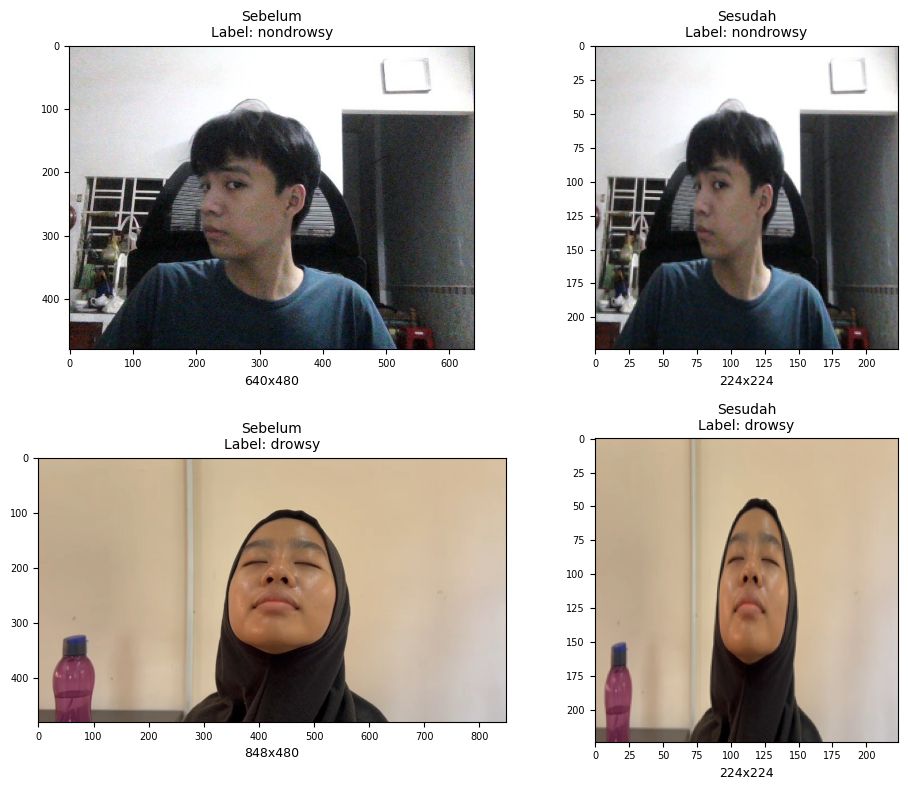

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

target_size = (224, 224)
classes_sample = os.listdir(image_dataset_primer)[:2]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, cls in enumerate(classes_sample):
    class_path = os.path.join(image_dataset_primer, cls)
    img_file = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_file)

    img_original = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img_original.size
    img_resized = img_original.resize(target_size)

    # Sebelum resize
    axes[row, 0].imshow(np.array(img_original))
    axes[row, 0].set_title(f'Sebelum\nLabel: {cls}', fontsize=10)
    axes[row, 0].set_xlabel(f'{orig_w}x{orig_h}', fontsize=9)
    axes[row, 0].tick_params(axis='both', labelsize=7)

    # Sesudah resize
    axes[row, 1].imshow(np.array(img_resized))
    axes[row, 1].set_title(f'Sesudah\nLabel: {cls}', fontsize=10)
    axes[row, 1].set_xlabel(f'{target_size[0]}x{target_size[1]}', fontsize=9)
    axes[row, 1].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

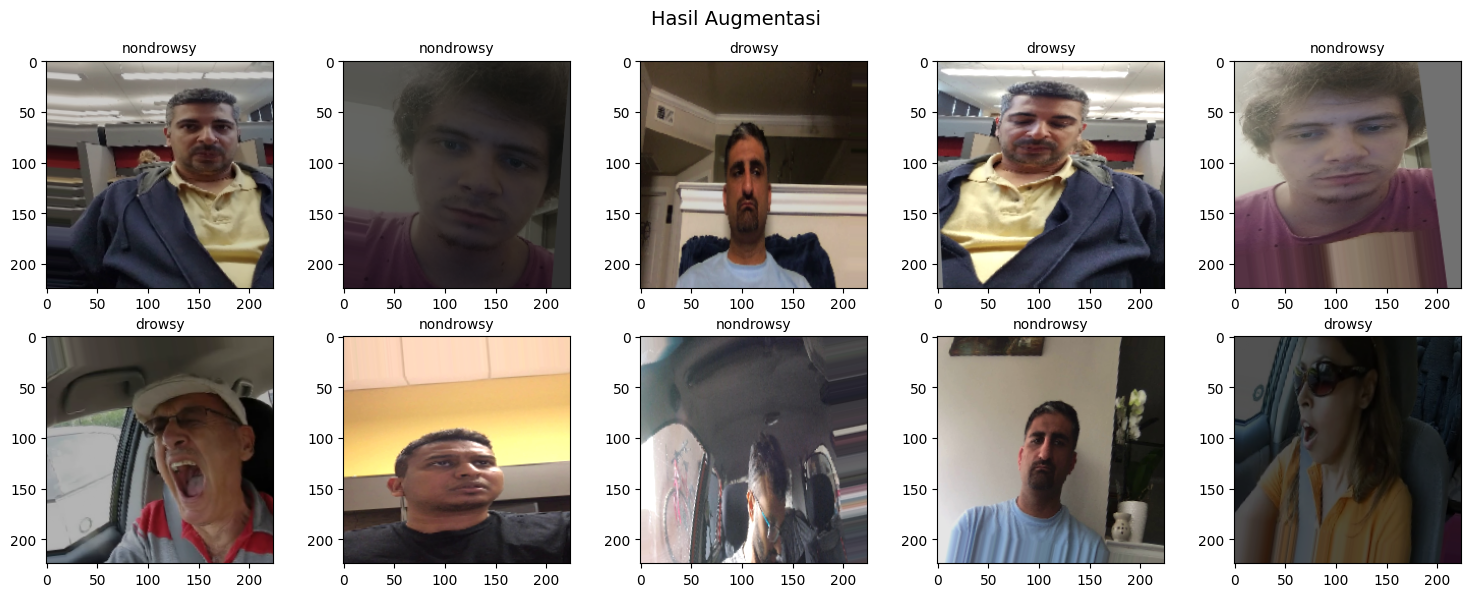

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

x_batch, y_batch = next(train_generator)
class_names = ['drowsy', 'nondrowsy']

for i in range(10):
    axes[i].imshow(x_batch[i])
    axes[i].set_title(f'{class_names[int(y_batch[i])]}', fontsize=10)

plt.suptitle('Hasil Augmentasi', fontsize=14)
plt.tight_layout()
plt.show()

## Modelling

In [15]:
from tensorflow.keras.applications import ResNet50

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet.trainable = True

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [16]:
# Bangun model CNN dengan Resnet50
model = Sequential([
    resnet,
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Kompilasi model
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callback
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Training model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,374,657 (108.24 MB)

 Trainable params: 28,320,513 (108.03 MB)

 Non-trainable params: 54,144 (211.50 KB)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.8443 - loss: 0.3647 - val_accuracy: 0.4981 - val_loss: 1.0781 - learning_rate: 1.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 261s 950ms/step - accuracy: 0.9202 - loss: 0.2127 - val_accuracy: 0.5184 - val_loss: 1.1545 - learning_rate: 1.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 259s 945ms/step - accuracy: 0.9319 - loss: 0.1841 - val_accuracy: 0.8784 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 250s 910ms/step - accuracy: 0.9385 - loss: 0.1695 - val_accuracy: 0.9403 - val_loss: 0.1557 - learning_rate: 1.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 246s 899ms/step - accuracy: 0.9485 - loss: 0.1457 - val_accuracy: 0.9296 - val_loss: 0.2017 - learning_rate: 1.0000e-04
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 252s 920ms/step - accuracy: 0.9441 - loss: 0.1450 - val_accuracy: 0.9509 - val_loss: 0.1293 - learning_rate: 1.0000e-04
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 243

## Evaluasi dan Visualisasi

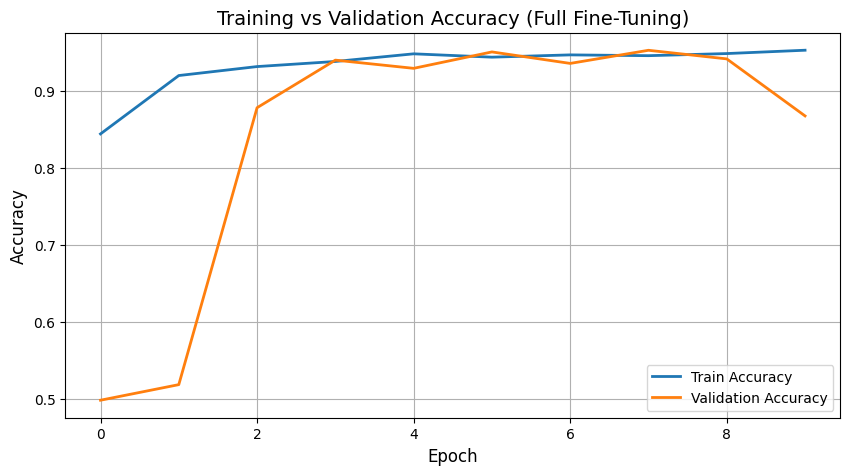

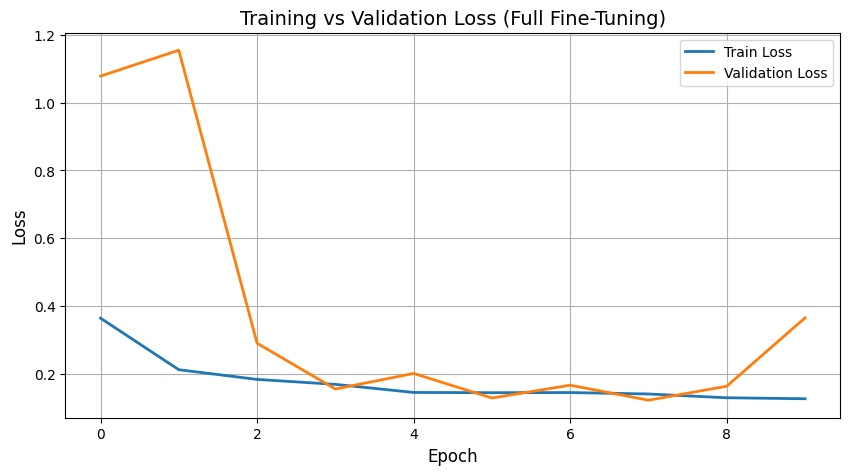

In [17]:
# Visualisasi
# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy (Full Fine-Tuning)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss (Full Fine-Tuning)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Prediksi pada data test
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

# Label sebenarnya dari generator
y_true = test_generator.classes

# Nama kelas
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("Classification Report (Full Fine-Tuning)")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

59/59 ━━━━━━━━━━━━━━━━━━━━ 29s 410ms/step
Classification Report (Full Fine-Tuning)
              precision    recall  f1-score   support

      drowsy       0.95      0.94      0.95       935
   nondrowsy       0.94      0.95      0.95       940

    accuracy                           0.95      1875
   macro avg       0.95      0.95      0.95      1875
weighted avg       0.95      0.95      0.95      1875



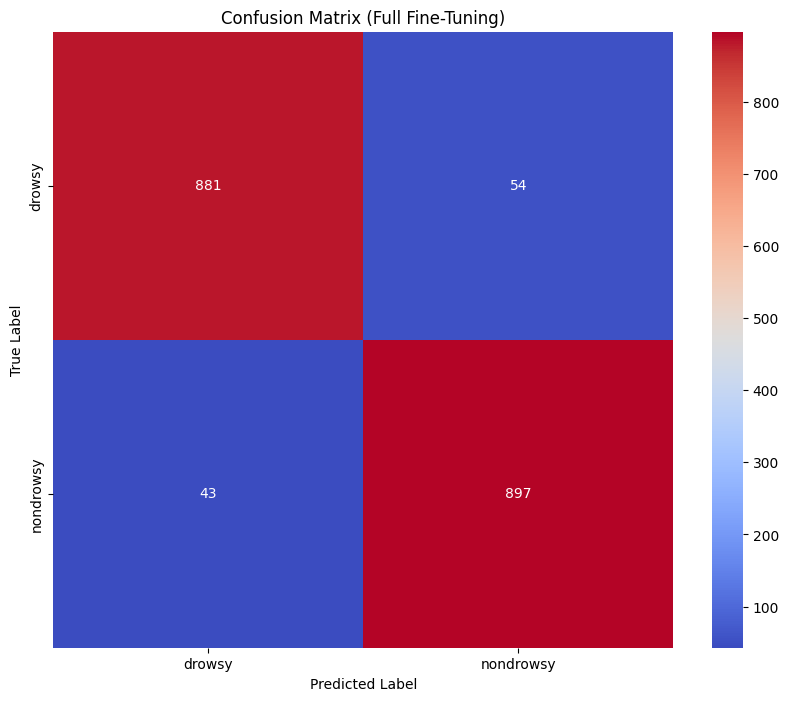

In [19]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix (Full Fine-Tuning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Konversi Model

In [20]:
model.save("/content/model.h5")
print("Saved:", round(os.path.getsize("/content/model.h5")/1024/1024, 2), "MB")

from google.colab import files
files.download("/content/model.h5")

Saved: 324.91 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>